# 1. Introduction
### Discover hidden customer segments using unsupervised learning.
- Identify patterns in customer behavior
- Group similar customers
- Provide actionable insights

# Dataset Overview

## People

- **ID**: Customer's unique identifier  
- **Year_Birth**: Customer's birth year  
- **Education**: Customer's education level  
- **Marital_Status**: Customer's marital status  
- **Income**: Customer's yearly household income  
- **Kidhome**: Number of children in customer's household  
- **Teenhome**: Number of teenagers in customer's household  
- **Dt_Customer**: Date of customer's enrollment with the company  
- **Recency**: Number of days since customer's last purchase  
- **Complain**: `1` if the customer complained in the last 2 years, `0` otherwise  

---

## Products

- **MntWines**: Amount spent on wine in the last 2 years  
- **MntFruits**: Amount spent on fruits in the last 2 years  
- **MntMeatProducts**: Amount spent on meat products in the last 2 years  
- **MntFishProducts**: Amount spent on fish products in the last 2 years  
- **MntSweetProducts**: Amount spent on sweet products in the last 2 years  
- **MntGoldProds**: Amount spent on gold products in the last 2 years  

---

## Promotion

- **NumDealsPurchases**: Number of purchases made with a discount  
- **AcceptedCmp1**: `1` if the customer accepted the offer in the 1st campaign, `0` otherwise  
- **AcceptedCmp2**: `1` if the customer accepted the offer in the 2nd campaign, `0` otherwise  
- **AcceptedCmp3**: `1` if the customer accepted the offer in the 3rd campaign, `0` otherwise  
- **AcceptedCmp4**: `1` if the customer accepted the offer in the 4th campaign, `0` otherwise  
- **AcceptedCmp5**: `1` if the customer accepted the offer in the 5th campaign, `0` otherwise  
- **Response**: `1` if the customer accepted the offer in the last campaign, `0` otherwise  

---

## Place

- **NumWebPurchases**: Number of purchases made through the company’s website  
- **NumCatalogPurchases**: Number of purchases made using a catalogue  
- **NumStorePurchases**: Number of purchases made directly in stores  
- **NumWebVisitsMonth**: Number of visits to the company’s website in the last month

In [140]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# EDA

In [141]:
df = pd.read_csv("../data/raw/marketing_campaign.csv",sep="\t")

In [142]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [143]:
df.shape

(2240, 29)

In [144]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [145]:
df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [146]:
df.duplicated().sum()

0

- There are 0 duplicates

In [147]:
df.describe().round(2)

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.00,2240.00,2216.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,...,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.0,2240.0,2240.00
mean,5592.16,1968.81,52247.25,0.44,0.51,49.11,303.94,26.30,166.95,37.53,...,5.32,0.07,0.07,0.07,0.06,0.01,0.01,3.0,11.0,0.15
std,3246.66,11.98,25173.08,0.54,0.54,28.96,336.60,39.77,225.72,54.63,...,2.43,0.26,0.26,0.26,0.25,0.11,0.10,0.0,0.0,0.36
min,0.00,1893.00,1730.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.0,11.0,0.00
25%,2828.25,1959.00,35303.00,0.00,0.00,24.00,23.75,1.00,16.00,3.00,...,3.00,0.00,0.00,0.00,0.00,0.00,0.00,3.0,11.0,0.00
50%,5458.50,1970.00,51381.50,0.00,0.00,49.00,173.50,8.00,67.00,12.00,...,6.00,0.00,0.00,0.00,0.00,0.00,0.00,3.0,11.0,0.00
75%,8427.75,1977.00,68522.00,1.00,1.00,74.00,504.25,33.00,232.00,50.00,...,7.00,0.00,0.00,0.00,0.00,0.00,0.00,3.0,11.0,0.00
max,11191.00,1996.00,666666.00,2.00,2.00,99.00,1493.00,199.00,1725.00,259.00,...,20.00,1.00,1.00,1.00,1.00,1.00,1.00,3.0,11.0,1.00


In [148]:
df["Age"] = 2026 - df["Year_Birth"]
df = df.drop(columns=['Year_Birth'])

Convert the year of born to Age

### Age distribution

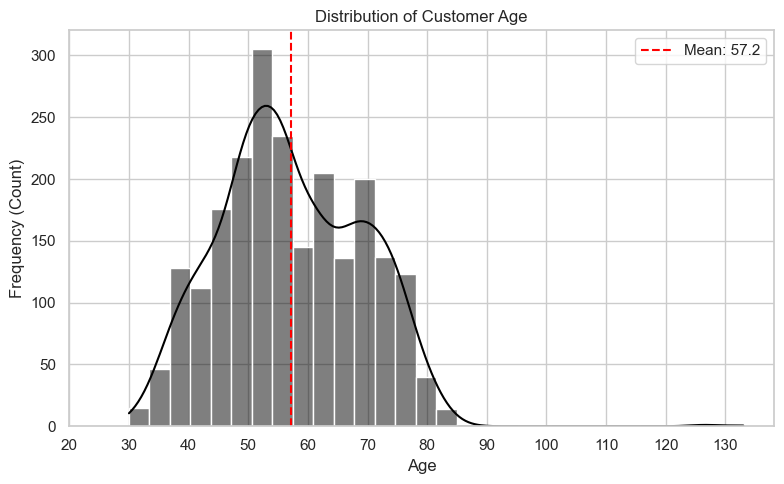

In [149]:
sns.set_theme(style="whitegrid") 

plt.figure(figsize=(8, 5))

ax = sns.histplot(df["Age"], bins=30, kde=True, color="black")

plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Frequency (Count)")
plt.xticks(range(20,140,10))

mean_val = df["Age"].mean()
plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.1f}')
plt.legend()

plt.tight_layout()
plt.show()


In [150]:
outlairs = df[df['Age']>100]
outlairs['Age'].value_counts()


Age
126    1
133    1
127    1
Name: count, dtype: int64

Age has some extrem values like >100

In [151]:
# Keep only rows where Age is 100 or less
df = df[df['Age'] <= 100]
outlairs = df[df['Age']>100]
outlairs['Age'].value_counts()


Series([], Name: count, dtype: int64)

### Distribution of Education

Text(0, 0.5, 'Count')

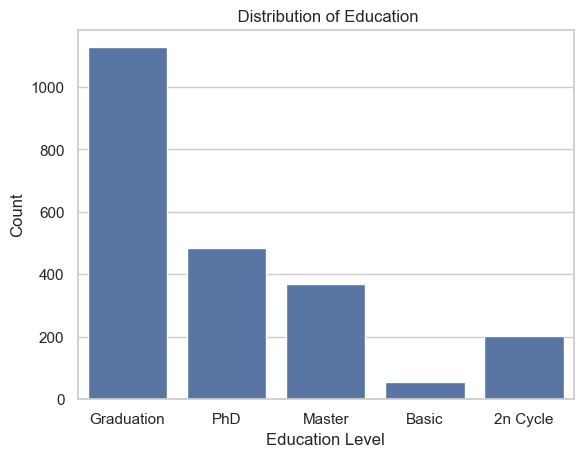

In [152]:
sns.countplot(data=df,x='Education')
plt.title(" Distribution of Education")
plt.xlabel("Education Level")
plt.ylabel("Count")


- most are graduate
- some has PhD adn Master 
- some are undergrate

In [153]:
edu_map = {
    'Basic': 'Undergraduate',
    '2n Cycle': 'Undergraduate',
    'Graduation': 'Graduate',
    'Master': 'Postgraduate',
    'PhD': 'Postgraduate'
}

df['Education_Group'] = df['Education'].replace(edu_map)

print(df['Education_Group'].value_counts())


Education_Group
Graduate         1127
Postgraduate      855
Undergraduate     255
Name: count, dtype: int64


In [154]:
df.drop(columns=["Education"], inplace=True)

### Distribution of Marital Status

Text(0, 0.5, 'Number of Customers')

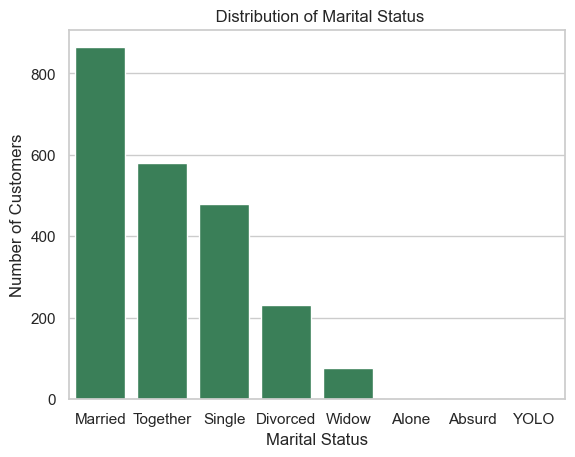

In [155]:
order = df['Marital_Status'].value_counts().index
sns.countplot(data=df, x='Marital_Status', order=order, color="seagreen")
plt.title(" Distribution of Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Number of Customers")



In [156]:
df['Marital_Status'].value_counts()

Marital_Status
Married     864
Together    579
Single      479
Divorced    231
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

- Most customers are Married.
- Together and Single are also common.
- Divorced and Widow are fewer.
- Absurd and YOLO appear as rare/inconsistent categories.

In [157]:
df['Marital_Status'] = df['Marital_Status'].replace('Alone','Single')
df = df[~df['Marital_Status'].isin(['Absurd', 'YOLO'])]

print(df['Marital_Status'].value_counts())


Marital_Status
Married     864
Together    579
Single      482
Divorced    231
Widow        77
Name: count, dtype: int64


convert alone to single and remove rare value

In [158]:
df["Marital_Status"] = df["Marital_Status"].replace({
    "Married": "Partnered",
    "Together": "Partnered"
})
print(df['Marital_Status'].value_counts())


Marital_Status
Partnered    1443
Single        482
Divorced      231
Widow          77
Name: count, dtype: int64


- Make Married and Together as Partnered 

### Distribution of Customer Annual Income

Text(0.5, 0, 'Annual Income')

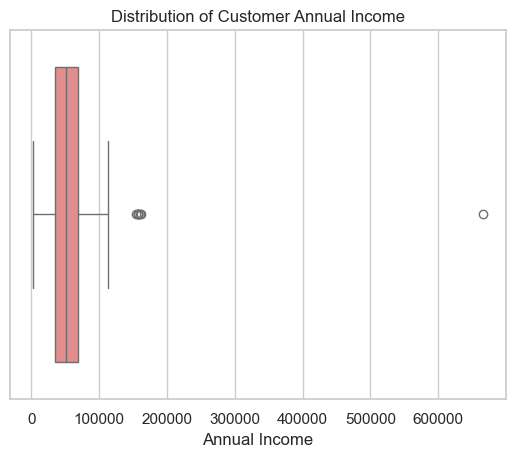

In [159]:
sns.boxplot(x=df["Income"], color="lightcoral")
plt.title("Distribution of Customer Annual Income")
plt.xlabel("Annual Income")


- there are some exteme values maybe they billioners
- need scaling


In [160]:
df[df['Income']>600000]

,ID,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Education_Group
2233,9432,Partnered,666666.0,1,0,02-06-2013,23,9,14,18,...,0,0,0,0,0,3,11,0,49,Graduate


- For clustering algorithms like K-Means, this can be a problem so remove it

In [161]:
df = df.dropna(subset=["Income"])     
df = df[df["Income"] < 600000]
df["Income"].max()

162397.0

missing data was small(1%) and income is an important feature for customer segmentation. extreme income values above 600,000 were removed to reduce the influence of outliers on distance-based clustering algorithms

### Distribution of Child at Home

Text(0, 0.5, 'Count')

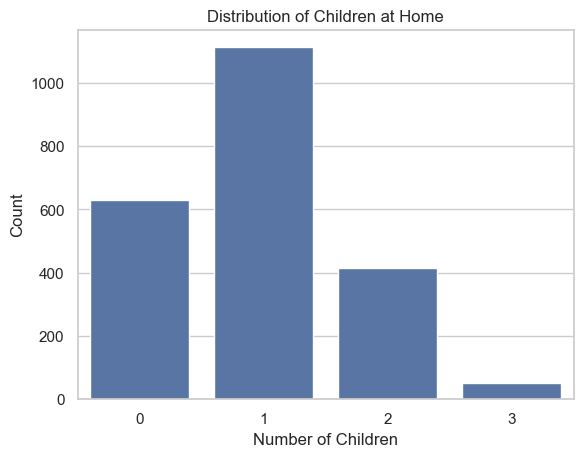

In [162]:
import sys
import os

sys.path.append(os.path.abspath('..'))

from src.feature_engineering import create_children

df = create_children(df)

sns.countplot(x="Total_Children", data=df)
plt.title("Distribution of Children at Home")
plt.xlabel("Number of Children")
plt.ylabel("Count")

- decide reduce feature by adding teen and child into one like Total_Children

### Distribution of customer's last purchase

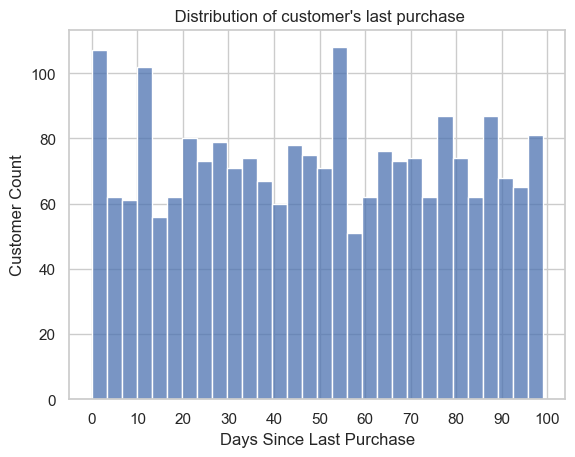

In [163]:
sns.histplot(df["Recency"], bins=30)
plt.title(" Distribution of customer's last purchase")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Customer Count")
plt.xticks(range(0,101,10))
plt.show()

it show how the last purachas has take place

### 

Text(0, 0.5, 'Number of Customers')

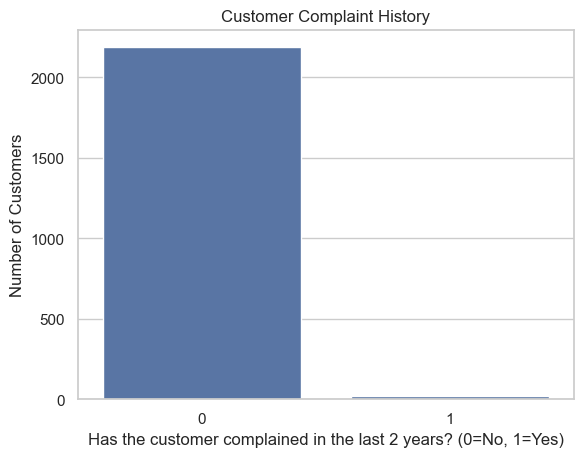

In [164]:
sns.countplot(data = df, x='Complain')
plt.title("Customer Complaint History")
plt.xlabel("Has the customer complained in the last 2 years? (0=No, 1=Yes)")
plt.ylabel("Number of Customers")


In [165]:
df['Complain'].value_counts()

Complain
0    2188
1      20
Name: count, dtype: int64

Most of the customers are very happy,out of 2188 only 20 customers has complain

In [166]:
df = df.drop(columns=['Complain'])

- Removing this column, and the reason is the extreme class imbalance.
- Because the feature has **very little variation**, it does not provide meaningful information for clustering.

### Distributions of Products Features

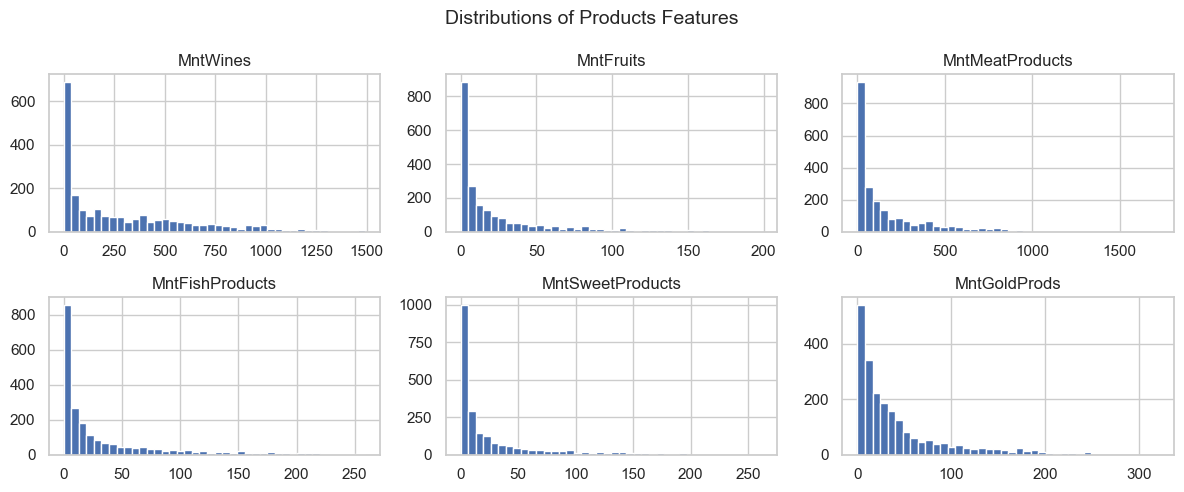

In [167]:
Products = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

df[Products].hist(bins=40, figsize=(12, 5), layout=(2, 3))
plt.suptitle("Distributions of Products Features",  fontsize=14)
plt.tight_layout()
plt.show()

This helps to identify the spendings on Products 

use log transform beacause it has right skwed so in cluster like distance-based clustering (like K-Means) causes problems because large values dominate the distance.

### Distribution of Purchases Made with Discounts

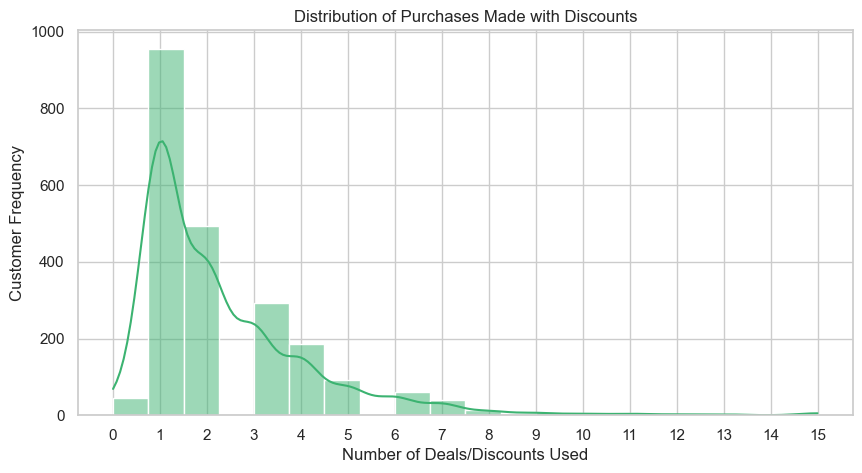

In [168]:
plt.figure(figsize=(10, 5))
sns.histplot(df["NumDealsPurchases"], bins=20, kde=True, color="mediumseagreen")
plt.title("Distribution of Purchases Made with Discounts")
plt.xlabel("Number of Deals/Discounts Used")
plt.ylabel("Customer Frequency")
plt.xticks(range(0,16))
plt.show()


- most are purchased in like in 1,2 deals offer, we can also see there is deal hunders

In [169]:
df["Total_Campaign_Accepted"] = ( df["AcceptedCmp1"] + df["AcceptedCmp2"] + df["AcceptedCmp3"] + df["AcceptedCmp4"] + df["AcceptedCmp5"])

df.drop(columns=["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5"], inplace=True)

In [170]:
df.columns

Index(['ID', 'Marital_Status', 'Income', 'Dt_Customer', 'Recency', 'MntWines',
       'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Z_CostContact', 'Z_Revenue', 'Response', 'Age', 'Education_Group',
       'Total_Children', 'Total_Campaign_Accepted'],
      dtype='object')

- Avoid adding **Response** it can act like an Target
- Clustering groups customers based on behavior, and **Response** helps us understand which groups respond to marketing campaigns.

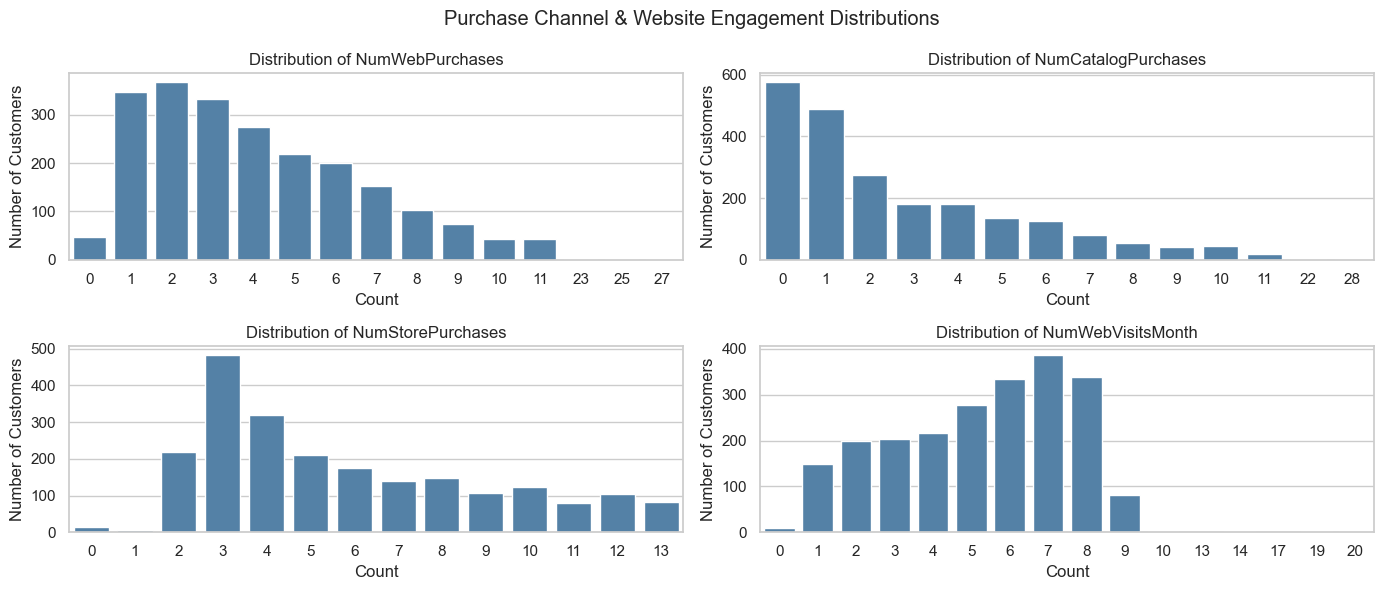

In [171]:
purchase_cols = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']

fig, axes = plt.subplots(2, 2, figsize=(14, 6))

axes = axes.flatten()

for i, col in enumerate(purchase_cols):
    sns.countplot(data=df, x=col, ax=axes[i], color="steelblue")
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel("Count")
    axes[i].set_ylabel("Number of Customers")

plt.suptitle("Purchase Channel & Website Engagement Distributions")
plt.tight_layout()
plt.show()


- Most customers make 1–5 web purchases.
- Many customers have 0–2 catalog purchases.
- Most customers make 3–6 store purchases.
- Most customers visit the website 4–8 times per month.

- its  help understand customer shopping behavior.
- Last chart shows Number of visits to company’s website in the last month
- show similar purachase pattern in purchases made through the company’s website and purchases made using a catalogue

In [172]:
unknown =  'Z_CostContact', 'Z_Revenue'

for i in unknown:
    print(df[i].value_counts())
    print(df[i].isna().sum())
    print('*'*30)

Z_CostContact
3    2208
Name: count, dtype: int64
0
******************************
Z_Revenue
11    2208
Name: count, dtype: int64
0
******************************


- Machine learning models need variation in data.
- But these columns have same value for all rows.
- They provide zero information for clustering.
- So removeing them.

In [173]:
df.drop(["Z_CostContact","Z_Revenue"], axis=1, inplace=True)

In [174]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

df["Customer_Tenure_Days"] = (df["Dt_Customer"].max() - df["Dt_Customer"]).dt.days

df["Customer_Tenure_Days"].head()

0    663
1    113
2    312
3    139
4    161
Name: Customer_Tenure_Days, dtype: int64

- Clustering algorithms cannot understand calendar meaning.
- Dates must be converted to numeric features.
- Customer_Tenure_Days very useful for clustering

### Prepare Data ready 
- Take only need column for final features

In [175]:
df.drop(["ID", "Dt_Customer", "Response"], axis=1, inplace=True)


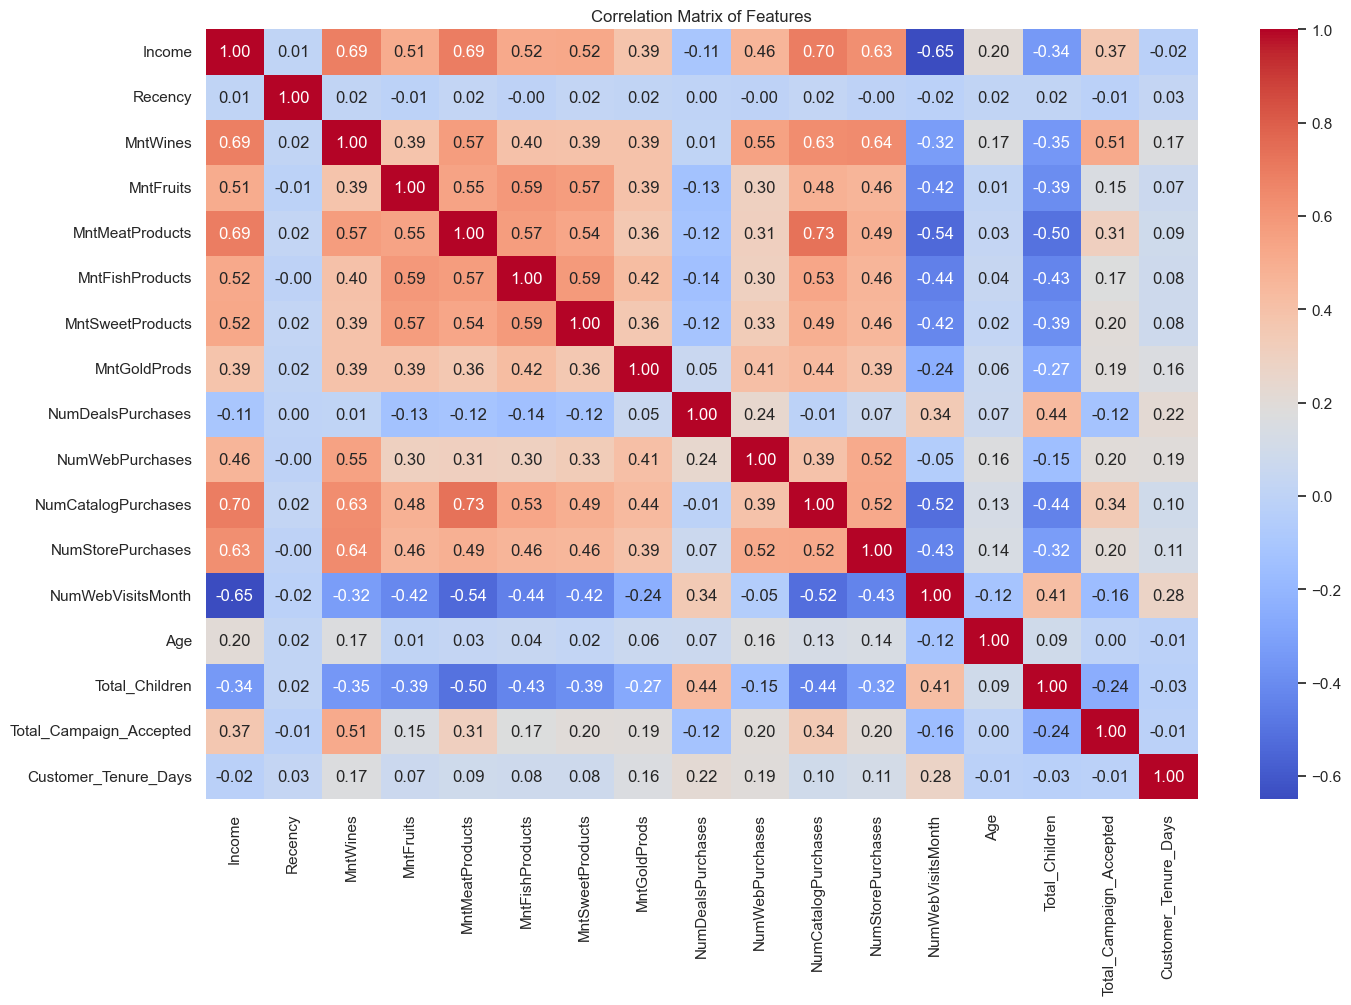

In [176]:
plt.figure(figsize=(16, 10))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix of Features")
plt.show()


## EDA Conclusion

Key findings before modelling:

- **Demographics:** Majority are graduates, aged 25-65, married, with 0-2 children.
- **Income:** Right-skewed (~median 51K); one extreme outlier (>600K) removed.
- **Spending:** All product columns are heavily right-skewed - log transform is using before distance-based clustering.
- **Campaigns:** Low acceptance rate overall; aggregated into Total_Campaign_Accepted.

> Response is excluded from clustering and will be used to evaluate segment quality.

## Feature Engineering And Preprocesing

### Total_Purchases

In [177]:
df['Total_Purchases'] = df[['NumWebPurchases','NumCatalogPurchases','NumStorePurchases','NumDealsPurchases']].sum(axis=1)


Total_Purchases was created to represent the overall number of purchases made by a customer across different channels.

### Total_Spending

In [178]:
df['Total_Spending'] = df[['MntWines','MntFruits','MntMeatProducts', 'MntFishProducts','MntSweetProducts','MntGoldProds']].sum(axis=1)


A new feature Total_Spending was created by summing all product spending columns. This feature represents the overall spending behavior of each customer and helps capture the customer's total purchasing value, which can improve clustering performance.

### Spending_Per_Purchase

In [179]:
df['Spending_Per_Purchase'] = df['Total_Spending'] / (df['Total_Purchases'] + 1)


- It capture the average amount spent per transaction.

In [180]:
import sys
import os

sys.path.append(os.path.abspath(".."))


from src.preprocessing import remove_duplicates

if df.duplicated().any():
    df = remove_duplicates(df)

Remove Duplicates if there is any.

In [181]:
df = pd.get_dummies(df, drop_first=True, dtype=int)


convert all categorical columns, Because this must be encoded before clustering

In [182]:
df.head()

,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,...,Total_Campaign_Accepted,Customer_Tenure_Days,Total_Purchases,Total_Spending,Spending_Per_Purchase,Marital_Status_Partnered,Marital_Status_Single,Marital_Status_Widow,Education_Group_Postgraduate,Education_Group_Undergraduate
0,58138.0,58,635,88,546,172,88,88,3,8,...,0,663,25,1617,62.192308,0,1,0,0,0
1,46344.0,38,11,1,6,2,1,6,2,1,...,0,113,6,27,3.857143,0,1,0,0,0
2,71613.0,26,426,49,127,111,21,42,1,8,...,0,312,21,776,35.272727,1,0,0,0,0
3,26646.0,26,11,4,20,10,3,5,2,2,...,0,139,8,53,5.888889,1,0,0,0,0
4,58293.0,94,173,43,118,46,27,15,5,5,...,0,161,19,422,21.100000,1,0,0,1,0


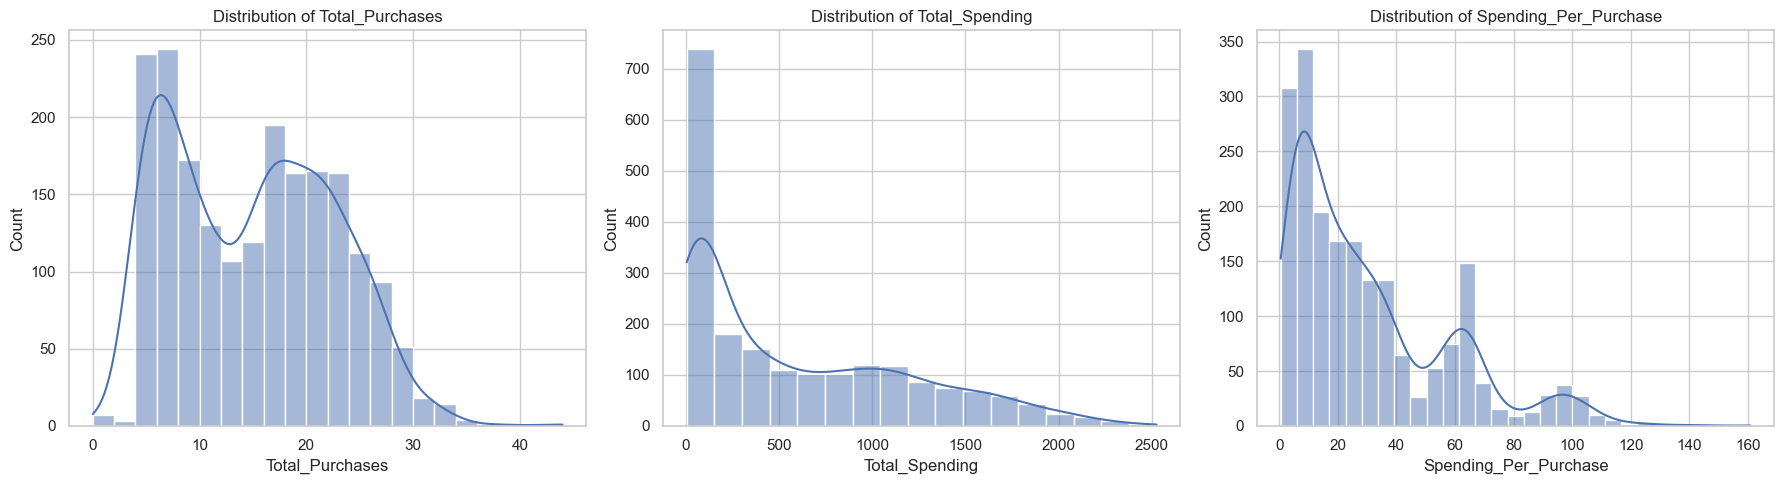

In [183]:
cols = ['Total_Purchases', 'Total_Spending', 'Spending_Per_Purchase']

plt.figure(figsize=(18, 5))

for i, col in enumerate(cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

- check any feature need log transform
- look good for `'Total_Purchases'` and `'Spending_Per_Purchase'`
- need for `Total_Spending` but we not using this in modeling it only created for create feature of `Spending_Per_Purchase`
- because it will be highly correlated

### Apply Log Transform 
- use np.log1p() because some values are 0.
- log transform fixes skewness


In [184]:
cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

df[cols] = np.log1p(df[cols])

In [185]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

X_scaled


,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,...,Total_Campaign_Accepted,Customer_Tenure_Days,Total_Purchases,Total_Spending,Spending_Per_Purchase,Marital_Status_Partnered,Marital_Status_Single,Marital_Status_Widow,Education_Group_Postgraduate,Education_Group_Undergraduate
0,0.282314,0.309737,0.983753,1.431674,1.389459,1.580396,1.408062,1.068707,0.349582,1.411550,...,-0.440610,1.538222,1.320941,1.676143,1.160031,-1.339875,1.895436,-0.188689,-0.785649,-0.359766
1,-0.263294,-0.381245,-1.214060,-0.992064,-1.397875,-0.858639,-0.973827,-0.905995,-0.169745,-1.123394,...,-0.440610,-1.181901,-1.160655,-0.963205,-0.987949,-1.339875,1.895436,-0.188689,-0.785649,-0.359766
2,0.905686,-0.795835,0.763205,1.063458,0.460621,1.318853,0.530991,0.503774,-0.689072,1.411550,...,-0.440610,-0.197711,0.798500,0.280110,0.168815,0.746338,-0.527583,-0.188689,-0.785649,-0.359766
3,-1.174551,-0.795835,-1.214060,-0.406935,-0.695300,-0.077074,-0.538837,-1.025710,-0.169745,-0.761259,...,-0.440610,-1.053314,-0.899435,-0.920046,-0.913137,0.746338,-0.527583,-0.188689,-0.785649,-0.359766
4,0.289484,1.553506,0.266254,0.981826,0.413997,0.796508,0.682334,-0.263990,1.388236,0.325146,...,-0.440610,-0.944509,0.537279,-0.307518,-0.353044,0.746338,-0.527583,-0.188689,1.272833,-0.359766
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2002,-1.166686,0.033344,-1.597762,-0.992064,-1.397875,-0.685588,-0.398801,-1.340598,-0.689072,-1.485529,...,-0.440610,1.627244,-1.421876,-0.971505,-0.967960,-1.339875,1.895436,-0.188689,-0.785649,-0.359766
2003,0.425030,-0.104852,1.044682,0.981826,0.689218,0.743003,1.590359,1.864569,-0.169745,1.773685,...,-0.440610,0.143540,0.406669,1.217992,1.468838,0.746338,-0.527583,-0.188689,-0.785649,-0.359766
2004,0.228789,1.449859,1.181457,1.050557,0.801138,0.583781,0.200837,0.082600,-0.689072,-0.761259,...,1.030777,-0.974183,0.537279,1.051995,1.154791,-1.339875,-0.527583,-0.188689,-0.785649,-0.359766
2005,0.796139,-1.417720,0.765792,0.758192,0.792277,1.123925,0.746209,0.787962,-0.169745,0.687280,...,-0.440610,-0.969237,1.059720,0.391328,0.163376,0.746338,-0.527583,-0.188689,1.272833,-0.359766


### Saving preprossed and feature engeneered cleaned data

In [186]:
df.to_csv("../data/processed/marketing_data_cleaned.csv", index=False)

# Modeling

## Reducing Dimentionality

In [187]:
from src.clustering import apply_pca, compute_elbow, compute_silhouette, run_kmeans, run_hierarchical
from src.evaluation import get_davies_bouldin
from src.clustering import plot_silhouette_scores
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import joblib

X_pca, pca = apply_pca(X_scaled)   
print("Components retained:", pca.n_components_)


Components retained: 14


In [188]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
print(cumulative_variance)

[0.36984242 0.45732149 0.53183089 0.59965326 0.64658053 0.6893923
 0.72955956 0.76579006 0.79599563 0.82521877 0.85153228 0.87281905
 0.89223879 0.91011467]


In [189]:
X_pca.shape

(2007, 14)

- These 14 components capture ~91% of the information in the original dataset.

# Clustering Experiments with KMeans

- n_init gives a better quality model (finds the "best" clusters)

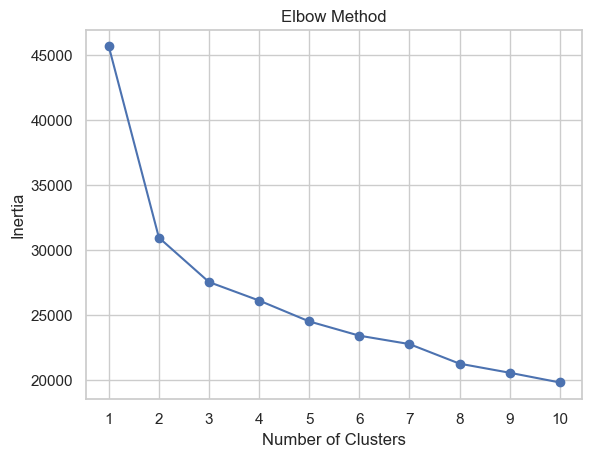

In [190]:
wcss = compute_elbow(X_pca)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(range(1,11))
plt.savefig('../outputs/reports/elbow_plot.png', dpi=150, bbox_inches='tight')
plt.show()


- Based on Elbow Method choose K=3

### KMeans silhouette_score plot
- used for Visual impact 

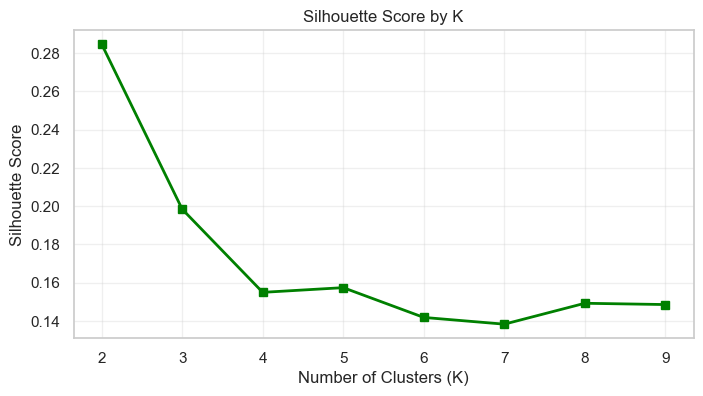

In [191]:
scores = plot_silhouette_scores(X_pca)

- from this we can see 2 is best
- but 2 only divede into 2 group its not much helpful
- so then better option is 3 so choose K=3

### compute_silhouette scores

In [192]:
scores = compute_silhouette(X_pca, KMeans, random_state=42, n_init=10)

for k, score in scores.items():
    print(f"K={k}, Silhouette Score={score:.3f}")

K=3, Silhouette Score=0.198
K=4, Silhouette Score=0.155
K=5, Silhouette Score=0.157
K=6, Silhouette Score=0.142


- -1 → very bad clustering
- 0 → overlapping clusters
-  1 → perfect clusters

This means clusters exist but separation is not very strong.


In [193]:
model, clusters = run_kmeans(X_pca, n_clusters=3)

df["KMeans_Cluster"] = clusters

df["KMeans_Cluster"].value_counts()

KMeans_Cluster
0    844
2    586
1    577
Name: count, dtype: int64

- Save the KMeans_Cluster in features

### Check for davies_bouldin_score

In [194]:
db_kmeans = get_davies_bouldin(X_pca, clusters,  "KMeans")

  KMeans DB Index: 1.8672 


- Based on the best, Silhouette Score=0.198 and Elbow Method choose K=3
-   KMeans DB Score: 1.8672  (lower is better)


### 2D scatter plot

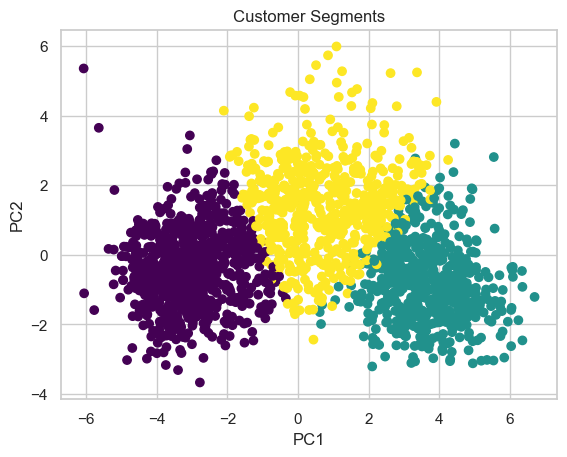

In [195]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segments")
plt.savefig('../outputs/reports/pca_clusters.png', dpi=150, bbox_inches='tight')

### Customer Segments — PCA Visualization

The model has identified 3 distinct customer segments.

- **Cluster 0** — spreads along the left side of PC1, indicating 
    likely lower spending or engagement
- **Cluster 1** — occupies the center-upper region, Higher spending or Possibly premium or active customers
- **Cluster 2** — concentrated on the right side of PC1, representing
  a mid-range customer group


# Hierarchical Clustering

## Dendrogram

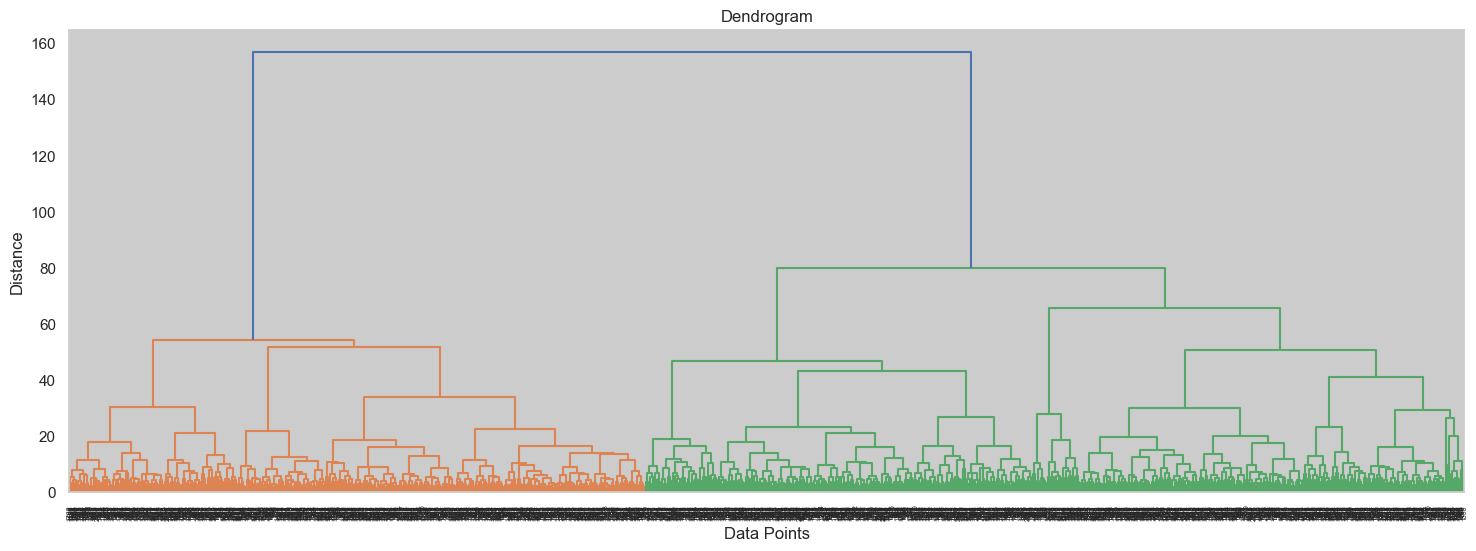

In [196]:
Z = linkage(X_pca, method='ward')

plt.figure(figsize=(18,6))
dendrogram(Z)

plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

- Choose to cut the line where 2nd line that comes after large one

In [197]:
hc_score = compute_silhouette(X_pca, AgglomerativeClustering, linkage='ward')

for k, score in hc_score.items():
    print(f"K={k}, Silhouette Score={score:.3f}")

K=3, Silhouette Score=0.170
K=4, Silhouette Score=0.173
K=5, Silhouette Score=0.127
K=6, Silhouette Score=0.135


- Based on K=4, Silhouette Score=0.173 and denderogram choose K=4

In [198]:
hc_model, hc_labels = run_hierarchical(X_pca, n_clusters=4)
df['HC_Cluster'] = hc_labels

### davies_bouldin_score

In [199]:
print(get_davies_bouldin(X_pca, hc_labels, "AgglomerativeClustering"))

  AgglomerativeClustering DB Index: 1.8978 
1.897768670710149


- KMeans optimal K=3 (silhouette peaks at 0.198)

- Agglomerative optimal K=4 (silhouette peaks at 0.173)

Each algorithm identified a different optimal number of clusters,
which is expected as they use different approaches to form groups.

### Customer Segments — Hierarchical Clustering (K=4) Visualization


Text(0.5, 1.0, 'Customer Segments (Hierarchical Clustering)')

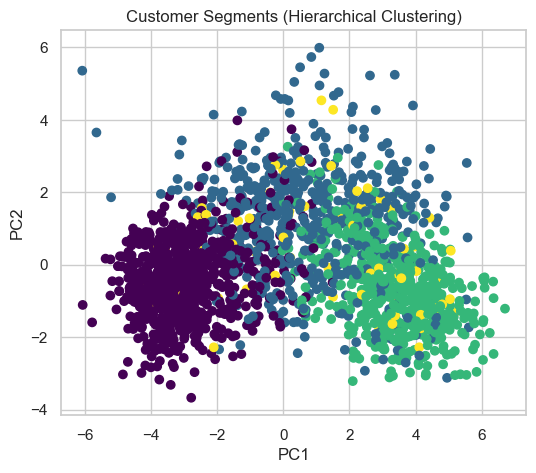

In [200]:
plt.figure(figsize=(6,5))

plt.scatter(X_pca[:,0], X_pca[:,1], c=hc_labels, cmap="viridis")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segments (Hierarchical Clustering)")

With K=4, the Hierarchical Clustering plot reveals **significant overlap**
between clusters, particularly in the central region.

The Agglomerative solution produces overlapping segments that are difficult to interpret meaningfully.

This visually confirms why **KMeans with K=3 is the better choice**
— cleaner boundaries, simpler interpretation, and stronger
silhouette score (0.198 vs 0.173).


## Cluster Evaluation — Model Comparison

### Silhouette Score Comparison

| K | KMeans | Agglomerative |
|---|--------|---------------|
| 3 | 0.198  | 0.170       |
| 4 | 0.155  | 0.173       |
| 5 | 0.157  | 0.127       |
| 6 | 0.142  | 0.135        |

 **Higher is better** (max = 1.0)

---

### Davies-Bouldin Index Comparison

| Model | DB Index |
|-------|----------|
| KMeans | 1.8672 |
| Agglomerative | 1.8978  |

 **Lower is better** (min = 0)

---


On the Davies-Bouldin Index, **KMeans (1.8672)** outperforms Agglomerative
Clustering (1.8978), meaning KMeans produces more compact and
well-separated clusters.

Visually, KMeans produces **cleaner cluster boundaries** while Agglomerative
with K=4 shows significant overlap and fragmentation in the PCA plot.

**KMeans with K=3 is chosen as the final model** — it achieves the highest
silhouette score, better DB Index, and cleaner visual separation,
making it the most suitable choice for customer segment interpretation.


## Create Cluster Profile Table

In [201]:
profile = df.groupby('KMeans_Cluster').agg({
    'Income':                       'mean',
    'Age':                          'mean',
    'Recency':                      'mean',
    'Total_Spending':               'mean',
    'Total_Purchases':              'mean',
    'Spending_Per_Purchase':        'mean',
    'Customer_Tenure_Days':         'mean',
    'Total_Children':               'mean',
    'Total_Campaign_Accepted':      'mean',
    'MntWines':                     'mean',
    'MntMeatProducts':              'mean',
    'MntFruits':                    'mean',
    'MntGoldProds':                 'mean',
    'NumWebPurchases':              'mean',
    'NumStorePurchases':            'mean',
    'NumCatalogPurchases':          'mean',
    'NumWebVisitsMonth':            'mean',
    'Marital_Status_Partnered':     'mean',
    'Education_Group_Postgraduate': 'mean',
}).round(2)

print(profile.T)

KMeans_Cluster                       0         1         2
Income                        34027.16  75468.71  54898.87
Age                              54.39     58.38     59.86
Recency                          48.95     49.28     48.91
Total_Spending                   76.99   1352.49    637.20
Total_Purchases                   7.29     20.83     19.98
Spending_Per_Purchase             8.70     64.13     29.43
Customer_Tenure_Days            310.55    353.62    410.04
Total_Children                    1.25      0.27      1.19
Total_Campaign_Accepted           0.08      0.66      0.26
MntWines                          2.89      6.26      5.69
MntMeatProducts                   2.61      5.90      4.58
MntFruits                         1.14      3.79      2.32
MntGoldProds                      2.18      3.94      3.64
NumWebPurchases                   1.88      5.21      6.22
NumStorePurchases                 3.05      8.38      7.18
NumCatalogPurchases               0.44      5.87      2.

### Cluster 0 — "Budget Conscious Families"
- Lowest income with minimal spending across all product categories.
- Has the highest number of children living at home, so they probably have less extra money to spend.
- Has visit the website many times(**6.44**), but they rarely end up buying something.may they are very sensitive to price.
- They rarely respond to marketing campaigns (**0.08**).

**Business Recommendation:** Since this group visits the website often but doesn’t buy much, the company should encourage them to purchase by offering discounts and affordable deals.

### Cluster 1 —"High Value Loyalists"
- Highest income segment with by far the greatest spending
- They have very few children 
- most campaign-responsive segment and heavily prefer catalogue purchases 
**Business Recommendation:** Target with premium product launches, exclusive catalogue offers, and personalized campaigns. This is the most valuable segment — focus retention efforts here.


### Cluster 2 —"Middle Class Actives"
- Mid-range income customers with moderate spending and high purchase frequency.
- They shop across all channels — web, store, and catalogue.
- They have some children at home and respond moderately to campaigns (0.26).

**Business Recommendation:** Reward loyalty with membership programs. Target with mid-range product promotions and campaign offers as they show willingness to respond.


### Cluster Feature Profiles

In [202]:
from sklearn.preprocessing import MinMaxScaler
heatmap_scaler  = MinMaxScaler()
profile_normalized = pd.DataFrame(heatmap_scaler.fit_transform(profile), columns=profile.columns, index=profile.index)

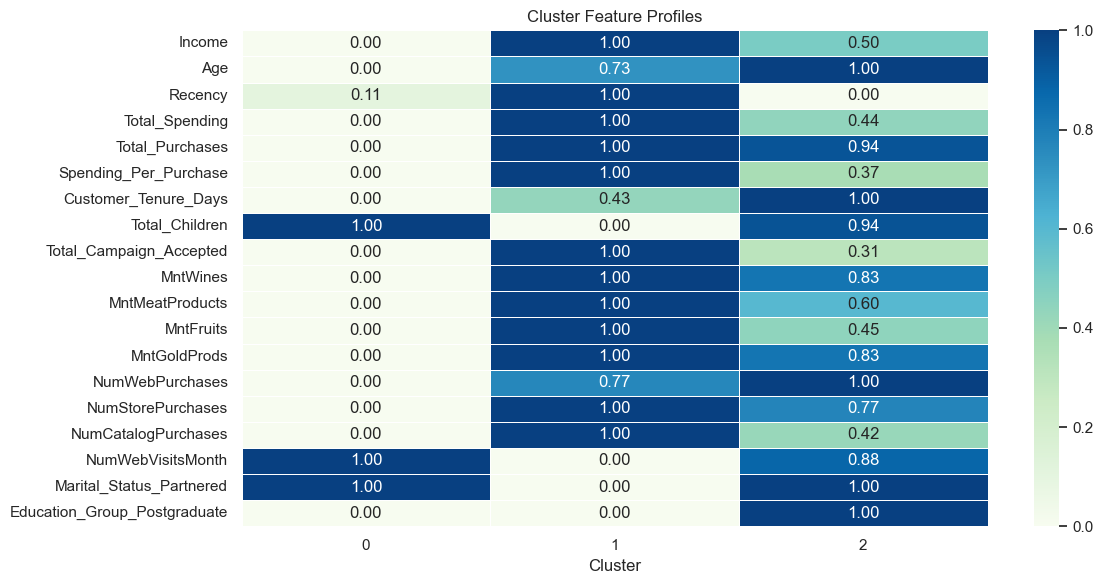

In [203]:
plt.figure(figsize=(12,6))
sns.heatmap(profile_normalized.T, annot=True, fmt='.2f', linewidths=0.5, cmap='GnBu')

plt.title('Cluster Feature Profiles')
plt.xlabel('Cluster')
plt.tight_layout()
plt.savefig('../outputs/reports/cluster_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


- 1.00 = highest value among all clusters for that feature
- 0.00 = lowest value among all clusters for that feature

### Feature Averages by Cluster

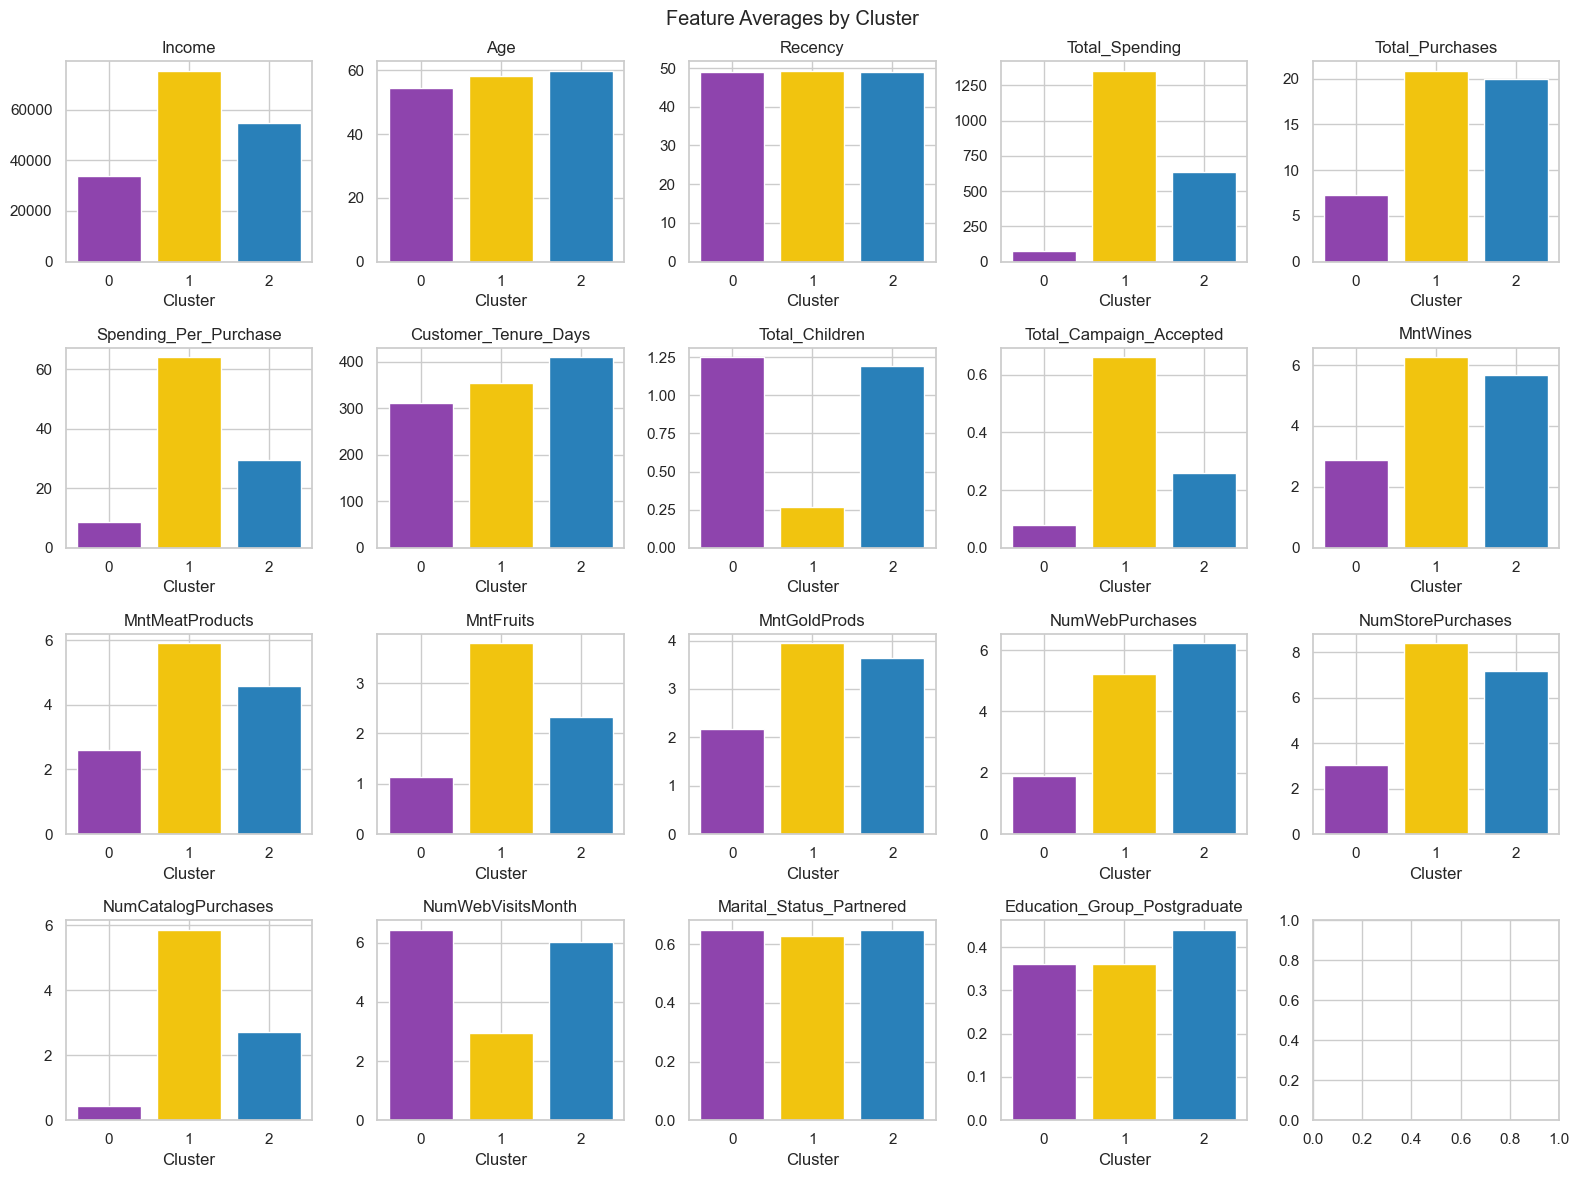

In [204]:
features = profile.columns.tolist()

fig, axes = plt.subplots(4, 5, figsize=(16, 12))
axes = axes.flatten()


for i, feature in enumerate(features):
    axes[i].bar(
        profile.index.astype(str),
        profile[feature],
        color = ['#8e44ad',  '#f1c40f', '#2980b9']
    )
    axes[i].set_title(feature)
    axes[i].set_xlabel('Cluster')

plt.suptitle('Feature Averages by Cluster')
plt.tight_layout()
plt.savefig('../outputs/reports/cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

### Feature Averages by Cluster — Analysis
- Cluster 1 dominates Total_Spending and Spending_Per_Purchase by a large margin, confirming the high-value segment
- Cluster 0 leads on both — most children and most web visits
- Cluster 1 has almost no children and lowest web visits
- Cluster 1 responds to campaigns more than Cluster 1
- Cluster 0 almost never responds (0.08)
- Cluster 1 prefers catalogue shopping over web
- Cluster 2 leads — most digitally active
- Recency is almost identical across all clusters 


## Key Insights

### What Discovered
- 3 different cluster identify from this dataset
- income and total spending differentiators between clusters
- low  icome family seprated by mainly number of childerns and number of vist in web per month
- Recency and Marital Status are not strong sepraters 
- Cluster 1 is the most campaign-responsive segment

### Business Recommendations

| Segment | Strategy |
|---------|----------|
| Cluster 0 — Budget Conscious Families | Discount deals, family bundles, price-driven promotions |
| Cluster 1 — High Value Loyalists | Premium products, exclusive catalogues, personalized campaigns |
| Cluster 2 — Middle Class Actives | Loyalty rewards, mid-range promotions, web campaigns |


### Limitations

- Silhouette scores are moderate (0.198), indicating some cluster overlap
- PCA reduces interpretability of original features

In [205]:
df.to_csv('../outputs/clusters/dataset_with_clusters.csv', index=False)

### Check DBSCAN

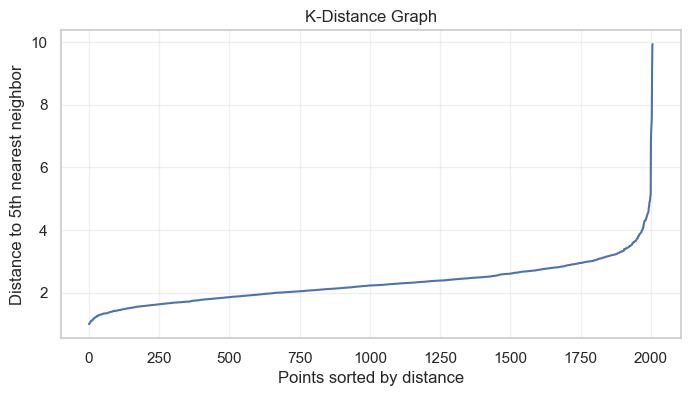

In [206]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

k=5
nbrs = NearestNeighbors(n_neighbors=k).fit(X_pca)
distances, indices = nbrs.kneighbors(X_pca)

distances = np.sort(distances[:, k-1])


plt.figure(figsize=(8, 4))
plt.plot(distances)
plt.title('K-Distance Graph')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'Distance to {k}th nearest neighbor')
plt.grid(True, alpha=0.3)
plt.show()


- Selecting eps for DBSCAN
- choose min sample as 5
- from graph we can clearly see bend ~ blow 4 likely to 3.7 or 3.8

In [207]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=3.7, min_samples=5)
db_labels = dbscan.fit_predict(X_pca)

print("Clusters found:", len(set(db_labels)) - (1 if -1 in db_labels else 0))
print("Noise points:", (db_labels == -1).sum())
print("Label counts:", pd.Series(db_labels).value_counts())

Clusters found: 2
Noise points: 30
Label counts:  0    1916
 1      61
-1      30
Name: count, dtype: int64


- Because of 2 group only choose KMeans from above
- there is high class imbalance
- DBSCAN identified 2 clusters with 41 noise points

- DBSCAN struggled to find well-defined clusters in this dataset,
producing one dominant cluster rather than meaningful segments.
This indicates the customer data does not have the density-based
structure that DBSCAN requires.


In [208]:
from src.preprocessing import preprocess
from src.feature_engineering import engineer_features, scale_features

df = pd.read_csv("../data/raw/marketing_campaign.csv", sep="\t")

response = df['Response'].copy()

df = preprocess(df)
df = engineer_features(df)
X_scaled, scaler = scale_features(df)
X_pca, pca = apply_pca(X_scaled)

model, clusters = run_kmeans(X_pca, n_clusters=3)

df_test = df.copy()
df_test["KMeans_Cluster"] = clusters
df_test["Response"] = response.loc[df.index].values

print(df_test.groupby('KMeans_Cluster')['Response'].mean().round(3) * 100)


KMeans_Cluster
0     8.9
1    26.1
2    12.9
Name: Response, dtype: float64


The `Response` column (last campaign acceptance) was excluded during 
modeling but used here to validate cluster quality.


- Cluster 1  shows the highest response rate at 26.1%, confirming they are the most marketing-responsive segment.
- Cluster 0  shows the lowest at 8.9%, consistent with their price-sensitive, low-engagement behavior. 
- Cluster 2 falls in between at 12.9%.
